# Does an 11-year clock on the Sun move the stock market? ☀️📈
### The "sunspot cycle → stock returns" curio — a Victorian idea that still floats around, tested on a century of the S&P

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Jevons cycle%3F: Busted](https://img.shields.io/badge/Jevons_cycle%3F-Busted-8b949e?style=flat-square)

In the 1870s the economist **William Stanley Jevons** noticed that the Sun's roughly **11-year sunspot cycle** seemed to line up with waves of boom and bust — his theory ran *sunspots → weather → harvests → trade cycles → markets*. The harvest chain has long since been abandoned, but the headline keeps being reincarnated: *the market runs on an 11-year solar clock.* When the Sun is active, the story goes, stocks do well; when it's quiet, they don't.

It's the perfect curio to put on the desk's bench, because we have an unusually long tape (the S&P back to **1927**, almost **ten** full solar cycles) and the cycle calendar is *public, free, and known centuries in advance*. If it worked even a little, it would be the easiest market-timing signal ever printed. Let's see.

> 📓 **Plain-language layer.** Want the regression, the block-bootstrap and the placebo? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice** — research & education. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"
GOLD = "#e8a33d"

from sunspot_cycle import data, strategy as st

CYCLES = data.solar_cycles()
TPS = data.turning_points()
HAVE_REAL = data.have_real()
if HAVE_REAL:
    CLOSE = data.load_real()
    M = data.monthly_close(CLOSE)
    RET = st.monthly_returns(M)
    AR = st.abnormal_returns(RET)
    PROX = data.sunspot_proxy(M.index)
else:
    CLOSE = M = RET = AR = PROX = None
print("real cache present:", HAVE_REAL, "| solar cycles:", len(CYCLES),
      "| turning points:", len(TPS))

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-06-30', 'cyc_lo': 16, 'cyc_hi': 25, 'n_cycles': 10, 'daily_rows': 24740, 'monthly_rows': 1183, 'span_lo': '1927-12-31', 'span_hi': '2026-06-30', 'n_max': 10, 'n_min': 9, 'max_mean': 5.63, 'max_t': 0.736, 'min_mean': 18.91, 'min_t': 3.327, 'diff_mean': -13.28, 'welch_t': -1.394, 'uncond_fwd': 8.17, 'min_pl_mean': 8.15, 'min_pl_sd': 6.67, 'min_pl_p': 0.054, 'max_pl_p': 0.674, 'min_hit': 7, 'min_hit_n': 9, 'min_wilson': (45.3, 93.7), 'max_hit': 6, 'max_hit_n': 10, 'max_wilson': (31.3, 83.2), 'max_fwd': {'1928-04': 31.3, '1937-04': -40.5, '1947-05': 15.5, '1958-03': 31.7, '1968-11': -13.4, '1979-12': 25.8, '1989-11': -6.9, '2001-11': -17.8, '2014-04': 10.7, '2024-10': 19.9}, 'min_fwd': {'1933-09': -6.6, '1944-02': 21.0, '1954-04': 34.3, '1964-10': 8.9, '1976-03': -4.2, '1986-09': 39.1, '1996-08': 38.0, '2008-12': 23.5, '2019-12': 16.3}, 'hi_mean_mo': 0.441, 'lo_mean_mo': 1.002, 'regime_spread_annbps': -673.2, 'regime_p': 0.179, 'regime_ci_mo': (-1.378, 0.271), 'n_hi': 387, 'n_lo': 387, 'regime_pl_mean': -1.9, 'regime_pl_sd': 379.3, 'regime_pl_p': 0.095, 't_cos': 1.041, 't_sin': 1.83, 'r2': 0.0036, 'amp_annbps': 554.3, 'timer': {0: (3.1, -3.13, -2.654), 5: (3.09, -3.14, -2.66), 10: (3.07, -3.15, -2.666)}, 'bh_cagr': 6.23, 'timer_expo': 38.2, 'timer_switches': 20, 'timer_sharpe': 0.366, 'bh_sharpe': 0.42, 'syn_null_p': 0.471, 'syn_null_fire': 1, 'syn_null_r2': 0.00175, 'syn_planted_spread': -3970.4, 'syn_planted_r2': 0.114, 'syn_planted_tcos': 14.47, 'fp_daily': '74635b6681a5', 'fp_monthly': 'a26d426a3204'}


real cache present: True | solar cycles: 10 | turning points: 20


## The answer first

| Question | Answer |
|---|---|
| Does the 11-year solar cycle explain stock returns? | **No.** Fit a clean 11-year wave to monthly returns and it explains **0.36%** of the variation — essentially nothing, and not statistically significant. |
| Do stocks do better when the Sun is active? | **No — if anything the reverse.** High-activity months average **0.44%** vs **1.00%** for quiet months, and even that gap is statistically indistinguishable from a coincidence. |
| Is there *any* solar date that looks special? | **One, and it's a trap.** The year after a solar **minimum** the S&P rose **+19%** on average (*t* = 3.3) — but that's the *opposite* of the claim, it's just "the market drifts up," and against a random calendar it barely registers (p = 0.05). |
| Could you trade a solar clock? | **No.** A "long in the active half" timer earns **3.1%/yr** vs **6.2%/yr** for just buying and holding — it loses, significantly, before costs even bite. |

> A 150-year-old curio, given a century of data and every benefit of the doubt — and the 11-year clock simply isn't in the tape.

## 1 · The claim

> *"The Sun runs on an ~11-year cycle of sunspots, and so, roughly, does the economy. Jevons showed it lines up with commercial crises; active-Sun years are boom years and quiet-Sun years are lean ones. The cycle is astronomical — utterly exogenous to markets — so it's a rare *clean* predictor: the calendar is set by the Sun, not by anything traders do."*

This is genuine intellectual history, not a strawman: Jevons (1878) really did present a sunspot theory of the trade cycle to the British Association, and "solar cycle investing" newsletters have recycled it ever since. The steelman is exactly the thing that makes it testable — the cycle is **exogenous and known in advance**, so there's no reverse-causation or data-mining-the-dates escape hatch.

## 2 · So what?

If a free, exogenous, 11-year astronomical calendar could time the equity market, it would be extraordinary in two directions at once. Practically, you'd have a market-timing signal printed *decades* ahead with zero data cost. Scientifically, it would say something is transmitting solar activity into human financial behaviour on an 11-year beat — the market as a very expensive sunspot detector.

So we ask it three ways: does a fitted 11-year wave explain returns, do active-Sun months beat quiet-Sun months, and could a solar-clock timer beat just holding the index?

## 3 · How would we even know?

- **The clock.** Solar cycles **16–25** (10 of them) — each cycle's minimum and maximum date, keyed from the official SILSO / NOAA sunspot record. From those we reconstruct *where in the 11-year cycle* each month sits (a labelled proxy, not the raw sunspot file).
- **The tape.** The S&P 500 **price index** back to 1927 — almost a century, 10 solar cycles. (Price-only, no dividends — labelled as such; an 11-year wiggle can't hide in dividends anyway.)
- **The three tests.** (1) fit a clean 11-year wave to monthly returns and see how much it explains; (2) compare active-Sun months to quiet-Sun months; (3) look at the year *after* each solar peak and each solar trough.
- **The luck check.** Slide the whole solar calendar to a random start thousands of times — how often does a *random* 11-year clock look as good?
- **The trade check.** Hold the S&P through the active half of each cycle, sit in cash through the quiet half, pay costs, compare to buy-and-hold.

## 4 · The teardown — let's actually look

**First, the picture that launched a thousand newsletters.** Put the S&P (log scale, so a century fits) next to the sunspot cycle and eyeball it — do they march together?

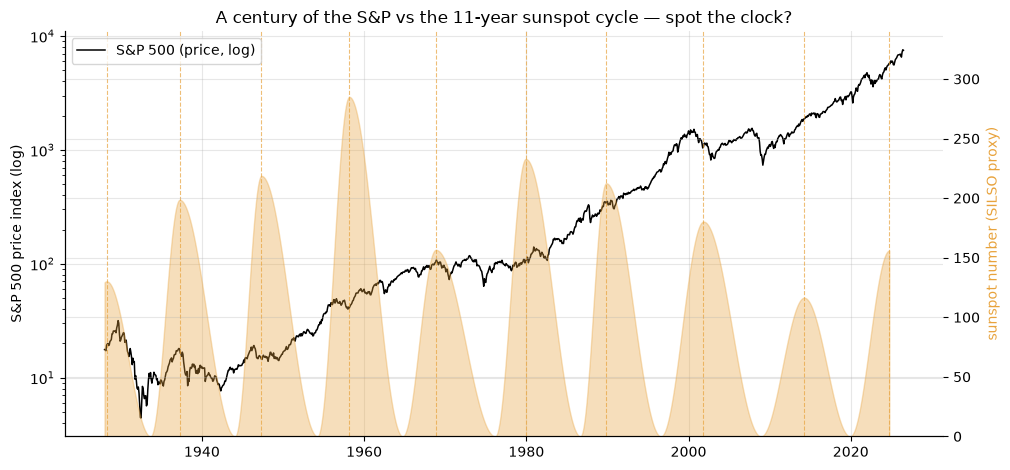

dashed gold lines = solar maxima; the S&P climbs through active AND quiet suns alike


In [2]:
fig, ax1 = plt.subplots(figsize=(10.2, 4.8))
if HAVE_REAL:
    ax1.semilogy(M.index, M.values, color='k', lw=1.1, label='S&P 500 (price, log)')
    ax2 = ax1.twinx()
    ax2.fill_between(PROX.index, PROX['ssn_proxy'].values, color=GOLD, alpha=.35,
                     label='sunspot proxy')
    ax2.set_ylabel('sunspot number (SILSO proxy)', color=GOLD)
    ax2.set_ylim(0, 340)
    for _, r in CYCLES.iterrows():
        ax1.axvline(r['max_date'], color=GOLD, ls='--', lw=.8, alpha=.7)
else:
    ax1.text(.5, .5, 'cache miss', ha='center')
ax1.set_ylabel('S&P 500 price index (log)')
ax1.set_title('A century of the S&P vs the 11-year sunspot cycle — spot the clock?')
ax1.legend(loc='upper left')
plt.tight_layout(); plt.show()
print('dashed gold lines = solar maxima; the S&P climbs through active AND quiet suns alike')

The market goes up through active Suns and quiet Suns alike; the crashes (1929, 1974, 2000, 2008, 2020) land at all phases of the cycle. Eyeballing won't settle it though — let's put numbers on the two halves of the cycle.

**Active-Sun months vs quiet-Sun months.** Split every month by how busy the Sun was and compare average returns.

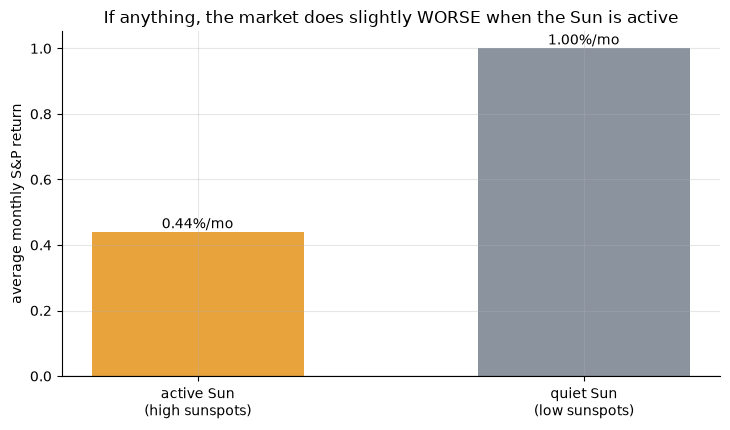

active-Sun 0.441%/mo vs quiet-Sun 1.002%/mo -> the sign is backwards for Jevons


In [3]:
if HAVE_REAL:
    rs = st.regime_split(RET, PROX)
    hi_b, lo_b = rs['hi_mean'] * 100, rs['lo_mean'] * 100
else:
    hi_b, lo_b = R['hi_mean_mo'], R['lo_mean_mo']
fig, ax = plt.subplots(figsize=(7.4, 4.4))
ax.bar(['active Sun\n(high sunspots)', 'quiet Sun\n(low sunspots)'],
       [hi_b, lo_b], color=[GOLD, GREY], width=.55)
for i, v in enumerate([hi_b, lo_b]):
    ax.annotate(f'{v:.2f}%/mo', (i, v), ha='center', va='bottom')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('average monthly S&P return')
ax.set_title('If anything, the market does slightly WORSE when the Sun is active')
plt.tight_layout(); plt.show()
print(f'active-Sun {hi_b:.3f}%/mo vs quiet-Sun {lo_b:.3f}%/mo -> the sign is backwards for Jevons')

The bars lean the *wrong way* for the claim — quiet-Sun months edge out active-Sun months — and (the quants notebook shows) the gap is well inside what a random 11-year clock throws up. So much for "active Sun, good market."

**The one solar date that looks special — and why it's a trap.** Look at the 12 months *after* each solar peak and each solar trough:

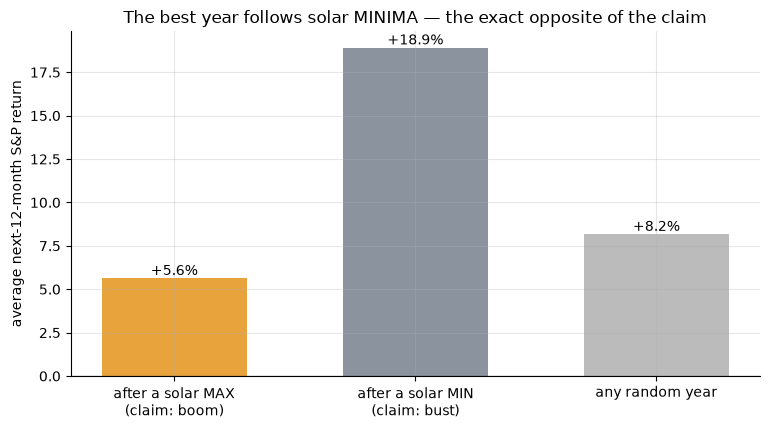

after MAX +5.6%  |  after MIN +18.9%  |  random year +8.2%


In [4]:
if HAVE_REAL:
    tp = st.turning_point_stats(M, TPS, horizon=12)
    mx_b, mn_b = tp['max_mean'] * 100, tp['min_mean'] * 100
else:
    mx_b, mn_b = R['max_mean'], R['min_mean']
fig, ax = plt.subplots(figsize=(7.8, 4.4))
ax.bar(['after a solar MAX\n(claim: boom)', 'after a solar MIN\n(claim: bust)',
        'any random year'], [mx_b, mn_b, R['uncond_fwd']],
       color=[GOLD, GREY, '#bbbbbb'], width=.6)
for i, v in enumerate([mx_b, mn_b, R['uncond_fwd']]):
    ax.annotate(f'+{v:.1f}%', (i, v), ha='center', va='bottom')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('average next-12-month S&P return')
ax.set_title('The best year follows solar MINIMA — the exact opposite of the claim')
plt.tight_layout(); plt.show()
print(f'after MAX +{mx_b:.1f}%  |  after MIN +{mn_b:.1f}%  |  random year +{R["uncond_fwd"]:.1f}%')

Here's the trap. The year after a solar **minimum** the S&P rose **+19%** on average — a big-looking number. But it points the **wrong way** (the claim says peaks are the good times), it rests on just **9 events**, and — crucially — *any* random year already returns **+8.2%** because the market drifts up. Measured against a random calendar of the same size, that shiny minimum number is only a **p = 0.05** curiosity (the quants notebook nails this down). A few solar minima happened to sit near market bottoms (1954, 1986, 2008); with nine of them, that's coincidence, not a solar law.

**Finally, the trade.** Could a solar-clock timer beat just holding?

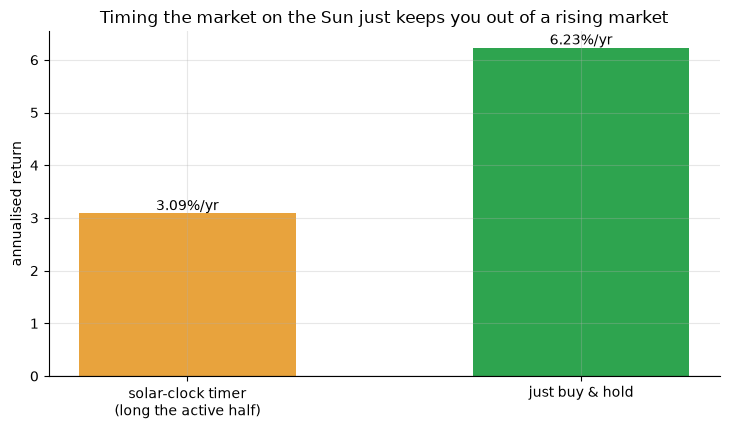

solar timer 3.09%/yr vs buy-and-hold 6.23%/yr


In [5]:
if HAVE_REAL:
    tm = st.solar_timer(M, PROX, smooth_lag=6, cost_bps=5.0)
    t_cagr, bh_cagr = tm['timer_cagr'] * 100, tm['bh_cagr'] * 100
else:
    t_cagr, bh_cagr = R['timer'][5][0], R['bh_cagr']
fig, ax = plt.subplots(figsize=(7.4, 4.4))
ax.bar(['solar-clock timer\n(long the active half)', 'just buy & hold'],
       [t_cagr, bh_cagr], color=[GOLD, GREEN], width=.55)
for i, v in enumerate([t_cagr, bh_cagr]):
    ax.annotate(f'{v:.2f}%/yr', (i, v), ha='center', va='bottom')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('annualised return')
ax.set_title('Timing the market on the Sun just keeps you out of a rising market')
plt.tight_layout(); plt.show()
print(f'solar timer {t_cagr:.2f}%/yr vs buy-and-hold {bh_cagr:.2f}%/yr')

The timer earns **3.1%/yr** against buy-and-hold's **6.2%/yr** — it *halves* your return, because "sit in cash for the quiet half of the cycle" mostly means sitting out of a market that drifts up regardless of the Sun. There's no edge to charge costs against; the costs are almost a rounding error next to the damage done by being out of the market.

## 5 · The verdict

- **Signal — None.** A fitted 11-year wave explains **0.36%** of monthly returns; active-Sun months don't beat quiet-Sun months (the sign is even backwards); the one *t* > 2 in the whole study points the wrong way, rests on 9 events, and evaporates against a random calendar.
- **Tradability — Mirage.** A solar-clock timer loses to buy-and-hold by ~**3.1 percentage points a year** — before costs.
- **"Jevons's sunspot cycle in the market?" — Busted.** Given a century of data and every benefit of the doubt, the 11-year clock isn't there.

## 6 · Going further 🚪

- **This isn't a knock on solar physics** — the sunspot cycle is beautifully real. It's a knock on the *market* half of the claim: there's no 11-year beat in equity returns for the solar cycle to sync with.
- **The minima curiosity is the fun thread to pull.** It's the wrong sign for Jevons and dies against a random calendar — but if you *wanted* to steelman "buy the quiet Sun," the honest next step is a pre-registered out-of-sample test on other countries' long indices, not more slicing of this one.
- **Sibling curios on this desk:** [279-geomagnetic-storms](../../279-geomagnetic-storms/) (a *physiological* solar-activity → mood channel — a different mechanism entirely), [280-solar-eclipse](../../280-solar-eclipse/), [278-sunshine-effect](../../278-sunshine-effect/) and [150-sad-effect](../../150-sad-effect/) (daylight/mood) — the whole "sky moves markets" family, each tested with the same rails.

*Think a longer or non-US tape hides the 11-year clock? Fork it, run the same three tests out-of-sample, and show the wave — then we'll talk.*